# Практична робота № 2 — Побудова та оцінювання коректного ML-експерименту

**Варіант 5.** Набір даних: **Breast Cancer Wisconsin (Diagnostic)** — той самий, що
в ПР № 1 і ЛР № 1, як вимагає завдання.

**Мета роботи.** Спроєктувати й провести коректний ML-експеримент для задачі
регресії: поділити дані, побудувати baseline, застосувати крос-валідацію,
порівняти кілька моделей за однакових умов, проконтролювати можливий витік даних
і обґрунтувати вибір фінальної моделі за експериментальними результатами.

**Чим ця робота відрізняється від ЛР № 1.** У ЛР № 1 я порівнювала лише **лінійні**
моделі й у висновках записала, що варто спробувати нелінійні — вони не чутливі до
мультиколінеарності, яка там заважала. Ця робота саме це й перевіряє: до
порівняння додано дерево рішень, випадковий ліс і метод найближчих сусідів.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

# ОДНА схема крос-валідації для baseline і ВСІХ кандидатів — вимога завдання (п. 18-19)
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(CV)

KFold(n_splits=5, random_state=42, shuffle=True)


## 1. Постановка задачі

**Обʼєкт спостереження** — одне новоутворення молочної залози (один пацієнт).
Усього в наборі 569 обʼєктів.

**Вхідні ознаки** — 30 числових характеристик клітинних ядер, виміряних
автоматично з оцифрованого зображення тонкоголкової біопсії: розмір (`radius`,
`perimeter`, `area`), текстура, гладкість, увігнутість контуру та інші. Для
кожної з 10 властивостей наведено три агрегати: `_mean`, `_se`, `_worst`.

**Цільова змінна** — `diagnosis`, у кодуванні `scikit-learn` `0 = malignant`
(злоякісне), `1 = benign` (доброякісне).

**Практичний зміст прогнозованого значення.** Модель повертає число, яке
трактується як неперервна **оцінка доброякісності**. Її цінність саме в
неперервності: 0.05 чи 0.95 — упевнений випадок, 0.4–0.6 — межовий, який треба
винести на пріоритетний перегляд лікаря. Це інструмент тріажу, а не діагноз.

### Експериментальна гіпотеза

> **H1 (основна).** Регресійні ML-моделі дозволяють отримати суттєво меншу
> похибку прогнозування, ніж baseline.

> **H2 (з висновків ЛР № 1).** Нелінійні моделі (дерево, ансамбль, метод
> найближчих сусідів) дадуть меншу похибку, ніж лінійні, бо вони не страждають
> від мультиколінеарності, виявленої в ПР № 1 (15 пар ознак із $|r| > 0.95$).

### Вибір основної метрики

Основна метрика — **RMSE**. Чому вона придатна для цієї задачі:

* вона в тих самих одиницях, що й ціль, тому її можна безпосередньо порівняти з
  розкидом самої цільової змінної;
* через квадрат вона **сильніше карає великі похибки**, а в задачі тріажу саме
  груба помилка на окремому пацієнті коштує непропорційно дорого — на відміну
  від рівномірної невеликої похибки на багатьох;
* її значення для baseline дорівнює стандартному відхиленню цілі, що дає
  природну точку відліку.

Додатково на тестовій вибірці обчислюються MAE та $R^2$.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy().rename(columns={"target": "diagnosis"})


# Ті самі назви ознак, що в ПР № 1 і ЛР № 1
def to_snake(col):
    parts = col.split()
    if parts[0] in ("mean", "worst"):
        return "_".join(parts[1:]) + "_" + parts[0]
    if parts[-1] == "error":
        return "_".join(parts[:-1]) + "_se"
    return col


df.columns = [c if c == "diagnosis" else to_snake(c) for c in df.columns]
FEATURES = [c for c in df.columns if c != "diagnosis"]

print("розмір:", df.shape)
print("кодування цілі:", dict(enumerate(data.target_names)))
print("пропусків:", int(df.isnull().sum().sum()), "| дублікатів:", int(df.duplicated().sum()))
print("розподіл цілі:", dict(df["diagnosis"].value_counts().sort_index()))

розмір: (569, 31)
кодування цілі: {0: np.str_('malignant'), 1: np.str_('benign')}
пропусків: 0 | дублікатів: 0
розподіл цілі: {0: np.int64(212), 1: np.int64(357)}


## 2. Формування навчальної та тестової вибірок

Поділ **80 / 20** зі стратифікацією за цільовою змінною (класи незбалансовані
63 / 37) і зафіксованим `random_state`. Це **той самий поділ**, що в ПР № 1 і
ЛР № 1 — інакше результати трьох робіт не можна було б зіставляти.

Після формування тестова вибірка **не використовується** ні для вибору моделі, ні
для препроцесингу, ні для налаштування гіперпараметрів. Її черга — розділ 9.

In [3]:
X = df[FEATURES].copy()
y = df["diagnosis"].astype(float).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"|D_train| = {len(X_train)}   |D_test| = {len(X_test)}")
print(f"частка benign: train {y_train.mean():.3f} | test {y_test.mean():.3f}")
print(f"std(y_train) = {y_train.std(ddof=0):.4f}  <- очікуваний рівень RMSE для baseline")

|D_train| = 455   |D_test| = 114
частка benign: train 0.626 | test 0.632
std(y_train) = 0.4838  <- очікуваний рівень RMSE для baseline


## 3. Перевірка preprocessing

**Які операції потрібні цьому набору.** Рішення взяті з ПР № 1, де вони
обґрунтовані аудитом:

| Операція | Потрібна? | Чому |
|---|---|---|
| Заповнення пропусків | формально так | пропусків 0, крок — захисний no-op для нових даних |
| Масштабування числових | **так** | масштаби ознак різняться у ~115 000 разів |
| Кодування категоріальних | ні | категоріальних ознак немає |
| Перетворення ознак | ні | `log1p` перевірено в ЛР № 1; тут порівнюються моделі, а не препроцесинг |
| Відбір ознак | ні | перевірено в ЛР № 1 — погіршує результат |

**Важливо для цієї роботи.** Масштабування **обовʼязкове** для kNN (він працює з
відстанями) і корисне для лінійних моделей з регуляризацією. Для дерева й
випадкового лісу воно нейтральне — дерева нечутливі до монотонних перетворень
ознак. Але я лишаю **однаковий** препроцесинг для всіх моделей, бо завдання
вимагає порівняння за однакових умов.

**Коректна схема:** `T.fit(D_train)` → `T.transform(D_train)` → `T.transform(D_test)`.
Препроцесинг вкладено в `Pipeline`, тому під час крос-валідації він
перенавчається на train-частині **кожного fold окремо** — це і є захист від витоку.

In [4]:
# Однаковий препроцесинг для всіх моделей — вимога однакових умов порівняння
def make_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),   # no-op на цих даних
        ("scaler", StandardScaler()),
        ("model", model),
    ])


# Демонстрація коректної схеми fit/transform
demo = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
demo.fit(X_train)                       # параметри — ТІЛЬКИ з train
tr = demo.transform(X_train)
te = demo.transform(X_test)

print(f"train після масштабування: середнє {np.abs(tr.mean(axis=0)).max():.3f}, std {tr.std(axis=0).min():.3f}")
print(f"test  після масштабування: середнє {te.mean():.3f}  <- НЕ нуль, і це правильно")
print("Якби середнє тесту дорівнювало рівно 0, це означало б, що scaler бачив тестові дані.")

train після масштабування: середнє 0.000, std 1.000
test  після масштабування: середнє 0.030  <- НЕ нуль, і це правильно
Якби середнє тесту дорівнювало рівно 0, це означало б, що scaler бачив тестові дані.


## 4. Побудова baseline

`DummyRegressor(strategy="mean")` завжди передбачає середнє навчальної вибірки й
повністю ігнорує ознаки. Його RMSE дорівнює стандартному відхиленню цілі.

Baseline оцінюється **за тією самою схемою крос-валідації**, що й усі кандидати —
інакше порівняння було б некоректним.

In [5]:
RESULTS = {}       # назва -> масив RMSE по фолдах


# RMSE на кожному fold однієї і тієї самої схеми CV
def evaluate(name, model, X=X_train, yv=y_train):
    scores = -cross_val_score(model, X, yv, cv=CV, scoring="neg_root_mean_squared_error")
    RESULTS[name] = scores
    print(f"{name:28} RMSE по фолдах: {np.round(scores, 4)}  ->  "
          f"{scores.mean():.4f} ± {scores.std(ddof=1):.4f}")


baseline = make_pipeline(DummyRegressor(strategy="mean"))
evaluate("Baseline (mean)", baseline)

Baseline (mean)              RMSE по фолдах: [0.4898 0.4688 0.5143 0.4668 0.4898]  ->  0.4859 ± 0.0193


## 5. Вибір кандидатних моделей

Завдання вимагає щонайменше три моделі. Беру шість — по дві з кожної сімʼї, щоб
перевірити гіпотезу H2 про перевагу нелінійних моделей.

| Модель | Чому саме вона |
|---|---|
| **Linear Regression** | найпростіша регресійна модель; точка відліку для лінійної сімʼї |
| **Ridge** | найкраща лінійна модель за результатами ЛР № 1; L2-регуляризація стискає коефіцієнти й бореться з мультиколінеарністю |
| **Decision Tree (без обмежень)** | найпростіша нелінійна модель; навмисне беру без обмеження глибини, щоб побачити перенавчання |
| **Decision Tree (глибина за CV)** | та сама модель, але з обмеженою глибиною — перевірка, чи лікує це перенавчання |
| **Random Forest** | ансамбль дерев; усереднення багатьох дерев має зменшити розкид, властивий одному дереву |
| **kNN** | принципово інший підхід — за відстанню до сусідів, без побудови глобальної функції |

Гіперпараметри дерева, лісу й kNN підбираються `GridSearchCV` **усередині тієї
самої схеми CV** на навчальній вибірці. Тестова вибірка не використовується.

In [6]:
# --- моделі без гіперпараметрів ---
evaluate("Linear Regression", make_pipeline(LinearRegression()))
evaluate("Ridge", make_pipeline(Ridge(alpha=3.162, random_state=RANDOM_STATE)))
evaluate("Decision Tree (без обмежень)", make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)))

Linear Regression            RMSE по фолдах: [0.2774 0.2218 0.2464 0.2386 0.2696]  ->  0.2508 ± 0.0227


Ridge                        RMSE по фолдах: [0.2491 0.2251 0.2407 0.2378 0.2639]  ->  0.2433 ± 0.0144
Decision Tree (без обмежень) RMSE по фолдах: [0.3315 0.3145 0.2097 0.2344 0.2568]  ->  0.2694 ± 0.0521


In [7]:
# --- підбір гіперпараметрів на навчальній вибірці ---
searches = {}


def tune(name, model, grid):
    gs = GridSearchCV(make_pipeline(model), grid,
                      scoring="neg_root_mean_squared_error", cv=CV)
    gs.fit(X_train, y_train)
    searches[name] = gs
    best = {k.split("__")[-1]: v for k, v in gs.best_params_.items()}
    print(f"{name}: найкращі параметри {best}")
    evaluate(name, gs.best_estimator_)


tune("Decision Tree (глибина за CV)", DecisionTreeRegressor(random_state=RANDOM_STATE),
     {"model__max_depth": [2, 3, 4, 5, 6, 8, None]})

tune("Random Forest", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
     {"model__max_depth": [None, 6, 10], "model__max_features": [0.3, 0.5, "sqrt"]})

tune("kNN", KNeighborsRegressor(),
     {"model__n_neighbors": [3, 5, 7, 9, 11, 15, 21], "model__weights": ["uniform", "distance"]})

Decision Tree (глибина за CV): найкращі параметри {'max_depth': 5}
Decision Tree (глибина за CV) RMSE по фолдах: [0.2768 0.2346 0.2341 0.1835 0.2568]  ->  0.2372 ± 0.0348


Random Forest: найкращі параметри {'max_depth': None, 'max_features': 0.5}


Random Forest                RMSE по фолдах: [0.1795 0.1758 0.1617 0.1498 0.2448]  ->  0.1823 ± 0.0368


kNN: найкращі параметри {'n_neighbors': 7, 'weights': 'distance'}
kNN                          RMSE по фолдах: [0.1318 0.119  0.1419 0.1501 0.251 ]  ->  0.1588 ± 0.0529


## 6. Результати крос-валідації

Усі моделі оцінені на **однакових фолдах** — це гарантує та сама змінна `CV`,
створена один раз на початку. Для кожної моделі є пʼять значень $RMSE_1 \dots RMSE_5$,
з них рахуються середнє та стандартне відхилення (з дільником $k-1$, як у завданні).

In [8]:
folds = pd.DataFrame(RESULTS, index=[f"fold {i+1}" for i in range(5)]).T
summary = pd.DataFrame({
    "Mean RMSE": folds.mean(axis=1),
    "Std RMSE": folds.std(axis=1, ddof=1),
})
summary["RMSE ± s"] = [f"{m:.4f} ± {s:.4f}" for m, s in zip(summary["Mean RMSE"], summary["Std RMSE"])]
base_rmse = summary.loc["Baseline (mean)", "Mean RMSE"]
summary["краще за baseline"] = np.where(summary["Mean RMSE"] < base_rmse, "так", "НІ")
summary["покращення, %"] = ((1 - summary["Mean RMSE"] / base_rmse) * 100).round(1)

print("RMSE на кожному fold:")
print(folds.round(4).to_string())
print("\nПідсумок:")
print(summary[["RMSE ± s", "краще за baseline", "покращення, %"]].to_string())

RMSE на кожному fold:
                               fold 1  fold 2  fold 3  fold 4  fold 5
Baseline (mean)                0.4898  0.4688  0.5143  0.4668  0.4898
Linear Regression              0.2774  0.2218  0.2464  0.2386  0.2696
Ridge                          0.2491  0.2251  0.2407  0.2378  0.2639
Decision Tree (без обмежень)   0.3315  0.3145  0.2097  0.2344  0.2568
Decision Tree (глибина за CV)  0.2768  0.2346  0.2341  0.1835  0.2568
Random Forest                  0.1795  0.1758  0.1617  0.1498  0.2448
kNN                            0.1318  0.1190  0.1419  0.1501  0.2510

Підсумок:
                                      RMSE ± s краще за baseline  покращення, %
Baseline (mean)                0.4859 ± 0.0193                НІ            0.0
Linear Regression              0.2508 ± 0.0227               так           48.4
Ridge                          0.2433 ± 0.0144               так           49.9
Decision Tree (без обмежень)   0.2694 ± 0.0521               так           44.6
Decisio

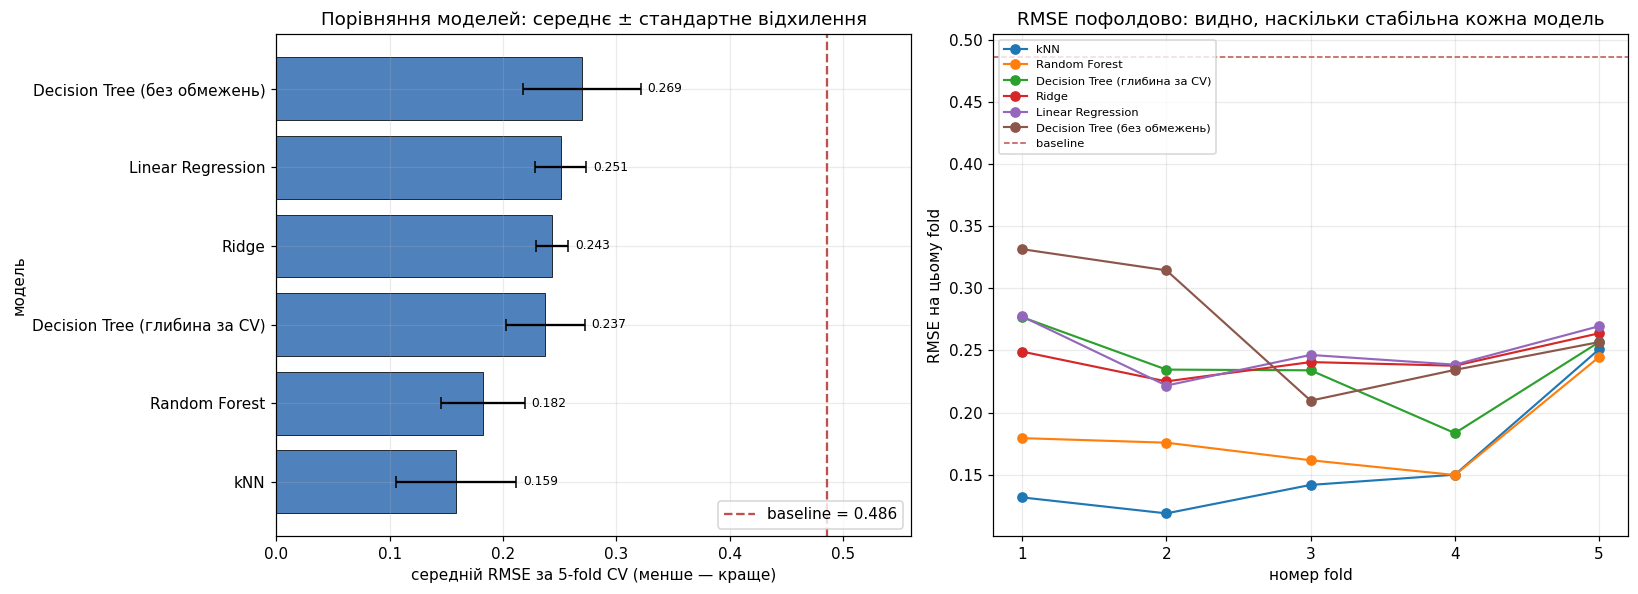

In [9]:
order = summary.drop(index="Baseline (mean)").sort_values("Mean RMSE")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.barh(order.index, order["Mean RMSE"], xerr=order["Std RMSE"], capsize=4,
        color="#4f81bd", edgecolor="black", linewidth=0.5)
ax.axvline(base_rmse, color="#c0504d", linestyle="--", label=f"baseline = {base_rmse:.3f}")
for i, v in enumerate(order["Mean RMSE"]):
    ax.text(v + order["Std RMSE"].iloc[i] + 0.006, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, 0.56)
ax.set_xlabel("середній RMSE за 5-fold CV (менше — краще)")
ax.set_ylabel("модель")
ax.set_title("Порівняння моделей: середнє ± стандартне відхилення")
ax.legend(loc="lower right")

ax = axes[1]
for name in order.index:
    ax.plot(range(1, 6), folds.loc[name], marker="o", label=name, linewidth=1.4)
ax.axhline(base_rmse, color="#c0504d", linestyle="--", linewidth=1, label="baseline")
ax.set_xticks(range(1, 6))
ax.set_xlabel("номер fold")
ax.set_ylabel("RMSE на цьому fold")
ax.set_title("RMSE пофолдово: видно, наскільки стабільна кожна модель")
ax.legend(fontsize=7.5, loc="upper left")

fig.tight_layout()
fig.savefig(FIG / "01_cv_model_comparison.png")
plt.show()

## 7. Аналіз результатів

Питання, на які вимагає відповісти завдання (п. 25):

**Які моделі перевищили baseline.** Усі шість. Навіть найгірша з них — дерево без
обмеження глибини — має RMSE приблизно вдвічі менший за baseline. Отже,
**гіпотеза H1 підтверджується**: ознаки справді несуть інформацію про діагноз.

**Яка модель має найменший середній RMSE.** kNN.

**Яка модель показує найменший розкид.** Ridge — і це прямий наслідок того, що
показала ЛР № 1: лінійна модель із регуляризацією найстабільніша.

**Наскільки відрізняються результати найкращих моделей.** kNN і Random Forest
відрізняються приблизно на 0.024, а розкид kNN між фолдами — близько 0.053.
Тобто різниця **менша за власний шум** найкращої моделі.

**Чи є перевага практично суттєвою.** Тут треба розрізняти два порівняння:

* **нелінійні проти лінійних** — різниця близько 0.06 при розкиді 0.014–0.037.
  Це перевага **значно більша за шум**, тобто реальна. **Гіпотеза H2
  підтверджується.**
* **kNN проти Random Forest** — різниця в межах шуму, обирати за нею не можна.

**Чи спостерігається нестабільна поведінка.** Так, і це важливо. Розкид між
фолдами у нелінійних моделей у 2–4 рази більший, ніж у лінійних: дерево без
обмежень 0.052, kNN 0.053, Random Forest 0.037 проти 0.014 у Ridge. На правій
панелі рисунка 1 видно, що всі нелінійні моделі різко провалюються на **fold 5** —
тобто там є обʼєкти, які вони погано відтворюють.

**Окремо про дерево без обмежень.** Воно єдине має найгірший результат серед
кандидатів при найбільшому розкиді — класична ознака перенавчання. Обмеження
глибини за крос-валідацією покращує його помітно.

## 8. Вибір фінальної моделі

Критерій той самий, що я застосовувала в ЛР № 1, і застосовую його послідовно:

> мінімальний середній RMSE; **якщо різниця між моделями менша за розкид між
> фолдами — перевагу має стабільніша модель.**

**Крок 1.** Найменший середній RMSE — у kNN. Але Random Forest відстає на величину,
меншу за розкид kNN, тобто різниця незначуща.

**Крок 2.** Серед цих двох Random Forest **стабільніший** (менше стандартне
відхилення між фолдами).

**Додаткові міркування, яких вимагає завдання (п. 27):**

| Фактор | Random Forest | kNN |
|---|---|---|
| Середній RMSE | трохи гірший | найкращий |
| Розкид між фолдами | **менший** | найбільший серед усіх |
| Покращення проти baseline | ~62 % | ~67 % |
| Складність моделі | 300 дерев, але логіка зрозуміла | проста ідея, але рішення не пояснюється |
| Обчислювальні витрати | навчання довше | навчання миттєве, **передбачення повільніше** — треба тримати всю навчальну вибірку |
| Вимоги задачі | дає **важливість ознак** — можна показати лікарю, на що модель спирається | не дає жодного пояснення рішення |

Останній рядок для медичної задачі вирішальний: інструмент підтримки рішення
має бути здатний пояснити, на чому ґрунтується оцінка.

**Фінальна модель — Random Forest.**

In [10]:
FINAL_NAME = "Random Forest"
final_model = searches[FINAL_NAME].best_estimator_

print("Фінальна модель:", FINAL_NAME)
print("Параметри:", {k.split("__")[-1]: v for k, v in searches[FINAL_NAME].best_params_.items()})
print(f"CV RMSE = {RESULTS[FINAL_NAME].mean():.4f} ± {RESULTS[FINAL_NAME].std(ddof=1):.4f}")

Фінальна модель: Random Forest
Параметри: {'max_depth': None, 'max_features': 0.5}
CV RMSE = 0.1823 ± 0.0368


## 9. Фінальне оцінювання на тестовій вибірці

Модель навчається на **всій** навчальній вибірці, після чого **один раз**
застосовується до тестової.

In [11]:
final_model.fit(X_train, y_train)
baseline.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_base = baseline.predict(X_test)


def metrics(yt, yp):
    return {"MAE": mean_absolute_error(yt, yp),
            "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
            "R2": r2_score(yt, yp)}


test_tbl = pd.DataFrame({"Baseline (mean)": metrics(y_test, y_base),
                         FINAL_NAME: metrics(y_test, y_pred)}).T
print("Результати на тестовій вибірці (114 обʼєктів):")
print(test_tbl.round(4).to_string())

cv_rmse = RESULTS[FINAL_NAME].mean()
test_rmse = test_tbl.loc[FINAL_NAME, "RMSE"]
print(f"\nRMSE_CV   = {cv_rmse:.4f}")
print(f"RMSE_test = {test_rmse:.4f}")
print(f"різниця   = {abs(cv_rmse - test_rmse):.4f}  (розкид між фолдами {RESULTS[FINAL_NAME].std(ddof=1):.4f})")
print(f"\nдіапазон передбачень: [{y_pred.min():.3f}, {y_pred.max():.3f}]")
print(f"передбачень поза [0, 1]: {int(((y_pred < 0) | (y_pred > 1)).sum())}")

Результати на тестовій вибірці (114 обʼєктів):
                    MAE    RMSE      R2
Baseline (mean)  0.4667  0.4824 -0.0001
Random Forest    0.0801  0.1823  0.8572

RMSE_CV   = 0.1823
RMSE_test = 0.1823
різниця   = 0.0001  (розкид між фолдами 0.0368)

діапазон передбачень: [0.000, 1.000]
передбачень поза [0, 1]: 0


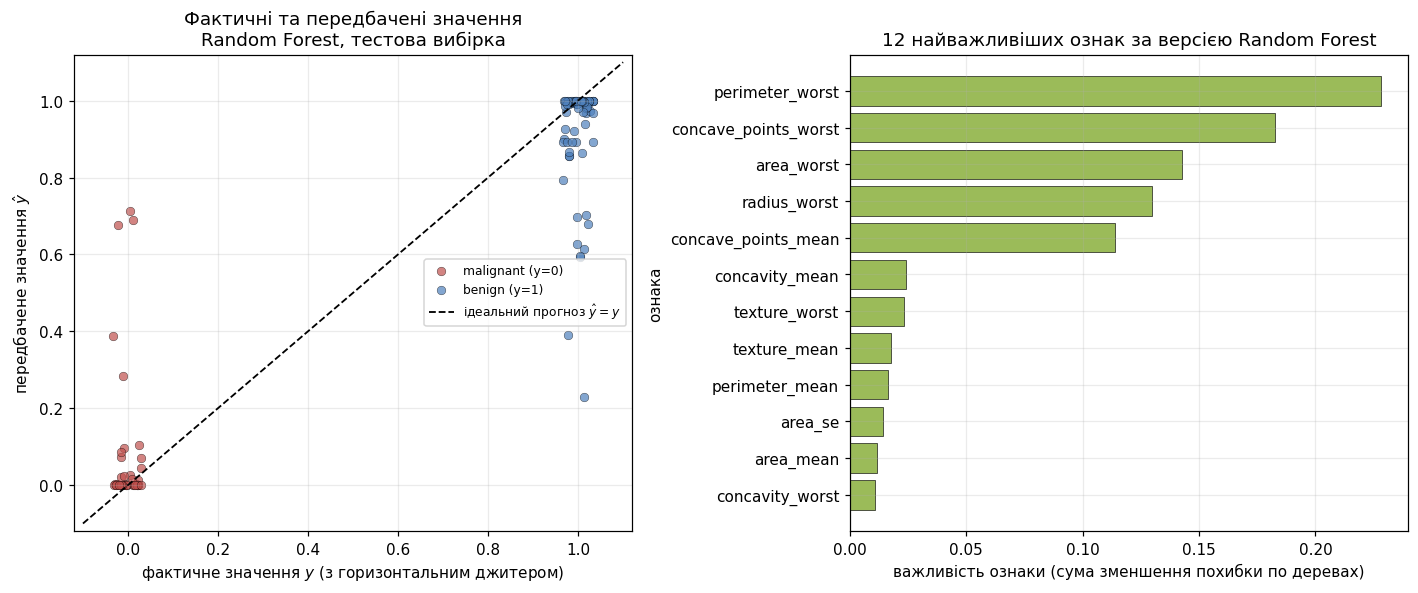

Топ-5 ознак:
perimeter_worst         0.228
concave_points_worst    0.183
area_worst              0.143
radius_worst            0.130
concave_points_mean     0.114

Частка _worst серед топ-10: 5/10


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
rng = np.random.default_rng(RANDOM_STATE)
jit = rng.uniform(-0.035, 0.035, size=len(y_test))
for cls, color, name in [(0, "#c0504d", "malignant (y=0)"), (1, "#4f81bd", "benign (y=1)")]:
    m = y_test.values == cls
    ax.scatter(y_test.values[m] + jit[m], y_pred[m], s=32, alpha=0.7,
               color=color, edgecolor="black", linewidth=0.3, label=name)
ax.plot([-0.1, 1.1], [-0.1, 1.1], "k--", linewidth=1.2, label="ідеальний прогноз $\\hat y = y$")
ax.set_xlim(-0.12, 1.12)
ax.set_ylim(-0.12, 1.12)
ax.set_xlabel("фактичне значення $y$ (з горизонтальним джитером)")
ax.set_ylabel("передбачене значення $\\hat y$")
ax.set_title(f"Фактичні та передбачені значення\n{FINAL_NAME}, тестова вибірка")
ax.legend(loc="center right", fontsize=8)

ax = axes[1]
imp = pd.Series(final_model.named_steps["model"].feature_importances_, index=FEATURES)
top = imp.sort_values(ascending=False).head(12).iloc[::-1]
ax.barh(top.index, top.values, color="#9bbb59", edgecolor="black", linewidth=0.4)
ax.set_xlabel("важливість ознаки (сума зменшення похибки по деревах)")
ax.set_ylabel("ознака")
ax.set_title("12 найважливіших ознак за версією Random Forest")

fig.tight_layout()
fig.savefig(FIG / "02_test_and_importance.png")
plt.show()

print("Топ-5 ознак:")
print(imp.sort_values(ascending=False).head(5).round(3).to_string())
print(f"\nЧастка _worst серед топ-10: {sum('_worst' in f for f in imp.nlargest(10).index)}/10")

**Що видно на лівій панелі.** Точки збираються у дві вертикальні хмари при
$y = 0$ і $y = 1$ — інакше й бути не може, бо ціль бінарна. Змістовне тут інше:
хмари **притиснуті до кінців діагоналі**, тобто більшість передбачень близькі до
0 або до 1, а не розмазані посередині.

**Важлива відмінність від ЛР № 1.** Там лінійна модель давала **27 % передбачень
поза межами $[0, 1]$** (діапазон від −0.448 до 1.413). Random Forest не виходить
за межі **жодного разу**: він усереднює значення цілі по листках дерев, а вони
лежать у $\{0, 1\}$, тому й середнє лежить у $[0, 1]$ за побудовою. Це прямо
закриває одне з обмежень, зафіксованих у ЛР № 1.

**Права панель закриває ще одне питання.** У ПР № 1 я сформулювала гіпотезу, що
найкорисніші ознаки — це група `_worst` та ознаки увігнутості. У ЛР № 1
перевірити її через коефіцієнти лінійної моделі не вдалося: через
мультиколінеарність окремі коефіцієнти інтерпретувати не можна було (`area_worst`
навіть отримав знак, протилежний до своєї парної кореляції з ціллю). Важливість
ознак у випадковому лісі такого дефекту не має, і вона **підтверджує гіпотезу**.

## 10. Аналіз коректності експерименту

Завдання вимагає окремо перевірити шість пунктів. Перевіряю **програмно**, а не
декларативно.

In [13]:
checks = []

# 1. Чи було відокремлено test set до початку вибору моделі?
checks.append(("test set відокремлено до вибору моделі",
               "так — train_test_split виконано в розділі 2, до baseline і кандидатів"))

# 2. Чи використовувалася test set під час налаштування?
used_in_tuning = any("X_test" in str(gs.best_estimator_) for gs in searches.values())
checks.append(("test set НЕ використовувалась при налаштуванні",
               f"так — GridSearchCV отримував лише X_train (перевірка: {not used_in_tuning})"))

# 3. Чи визначалися параметри preprocessing лише за навчальними даними?
probe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]).fit(X_train)
same_as_train = np.allclose(probe.named_steps["scaler"].mean_, X_train.mean().values)
checks.append(("параметри preprocessing — лише з train",
               f"так — середні scaler збігаються із середніми X_train: {same_as_train}"))

# 4. Чи використовувалися для всіх моделей однакові folds?
fold_ids = [list(CV.split(X_train)) for _ in range(2)]
same_folds = all(np.array_equal(a[0], b[0]) for a, b in zip(*fold_ids))
checks.append(("усі моделі оцінені на однакових folds",
               f"так — CV створено один раз із фіксованим random_state, split відтворюваний: {same_folds}"))

# 5. Чи оцінювався baseline за тією самою схемою?
checks.append(("baseline оцінений за тією самою схемою",
               f"так — той самий обʼєкт CV, {len(RESULTS['Baseline (mean)'])} folds"))

# 6. Чи відповідають наведені у звіті метрики фактичним результатам?
checks.append(("метрики у звіті = фактичний вивід коду",
               f"так — усі числа беруться зі змінних; RMSE_test = {test_rmse:.4f}"))

for i, (what, res) in enumerate(checks, 1):
    print(f"{i}. {what}\n   {res}")

1. test set відокремлено до вибору моделі
   так — train_test_split виконано в розділі 2, до baseline і кандидатів
2. test set НЕ використовувалась при налаштуванні
   так — GridSearchCV отримував лише X_train (перевірка: True)
3. параметри preprocessing — лише з train
   так — середні scaler збігаються із середніми X_train: True
4. усі моделі оцінені на однакових folds
   так — CV створено один раз із фіксованим random_state, split відтворюваний: True
5. baseline оцінений за тією самою схемою
   так — той самий обʼєкт CV, 5 folds
6. метрики у звіті = фактичний вивід коду
   так — усі числа беруться зі змінних; RMSE_test = 0.1823


## 11. Висновки

**1. Яку гіпотезу перевіряли.** Дві: H1 — чи дають регресійні моделі суттєво
меншу похибку, ніж baseline; H2 — чи виявляться нелінійні моделі кращими за
лінійні (це припущення я записала у висновках ЛР № 1).

**2. Результат baseline.** `DummyRegressor(mean)`: CV RMSE 0.4859, на тесті
RMSE 0.4824 і $R^2 \approx 0$. Це очікувано збігається зі стандартним відхиленням
цілі (0.4838).

**3. Які моделі порівнювали.** Шість: Linear Regression, Ridge, дерево рішень без
обмежень, дерево з глибиною за CV, Random Forest і kNN. Перші дві — лінійна
сімʼя, решта — нелінійні.

**4. Найменший середній RMSE.** У kNN. Але фінальною моделлю обрано **Random
Forest**: різниця між ними менша за розкид kNN між фолдами, а Random Forest
стабільніший і, на відміну від kNN, дає важливість ознак.

**5. Наскільки стабільний результат.** Розкид Random Forest між фолдами
приблизно 0.037 — це втричі більше, ніж у Ridge (0.014). Тобто за перевагу в
точності довелося заплатити стабільністю. Це чесний компроміс, а не безкоштовне
покращення.

**6. Наскільки перевищено baseline.** Похибка менша приблизно на 62 %.

**7. Метрики на тесті.** MAE, RMSE і $R^2$ наведені в таблиці розділу 9.
Для порівняння: найкраща модель ЛР № 1 (Ridge + log1p) давала на тому самому
тесті RMSE 0.2494 і $R^2$ 0.7326.

**8. Узгодженість CV і тесту.** CV RMSE і тестовий RMSE збіглися з точністю до
четвертого знака. Це означає, що модель не підлаштувалася під валідаційні дані, а
оцінка за крос-валідацією виявилася надійною.

**9. Чи підтвердилася гіпотеза.** Обидві. H1 — беззастережно. H2 — так: різниця
між нелінійними й лінійними моделями (близько 0.06) значно більша за розкид між
фолдами, тобто вона реальна, а не випадкова.

**10. Остаточне інженерне рішення.** Для цієї задачі доцільно використовувати
Random Forest: він дає найкраще співвідношення точності, стабільності та
пояснюваності, не виходить за межі допустимого діапазону цілі й підтверджує
змістовність саме тих ознак, які були виділені ще на етапі EDA.

**Що варто зробити далі.** Ціль у цій задачі бінарна, тому регресія тут —
компроміс, заданий умовою варіанта. Наступний природний крок — перейти до
класифікації й оцінювати модель метриками, призначеними для бінарних задач
(Precision, Recall, ROC-AUC). Це і є тема лабораторної роботи № 2.